# classification finetuning

this notebook explores how to fine-tune a pre-trained model for classification tasks

In [1]:
from pathlib import Path
import urllib.request

import torch

from functions import gpt_model


# define the GPT-2 small architecture

gpt2_config = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,
    "qkv_bias": True,
}


# create the models folder

models_folder = Path("./models")

models_folder.mkdir(
    parents=True,
    exist_ok=True,
)


# define the pretrained-weights file

weights_path = (
    models_folder
    / "gpt2-small-124M.pth"
)

weights_url = (
    "https://huggingface.co/"
    "rasbt/gpt2-from-scratch-pytorch/"
    "resolve/main/"
    "gpt2-small-124M.pth"
)


# download the weights once

if not weights_path.exists():
    print(
        "downloading GPT-2 small weights..."
    )

    urllib.request.urlretrieve(
        weights_url,
        weights_path,
    )

    print("download complete")
else:
    print(
        "pretrained weights already exist"
    )


# load the official weights

official_state_dict = torch.load(
    weights_path,
    map_location="cpu",
    weights_only=True,
)


# translate the official parameter names
# into the names used in functions.py

name_replacements = [
    (
        "tok_emb.",
        "token_embedding.",
    ),
    (
        "pos_emb.",
        "position_embedding.",
    ),
    (
        "trf_blocks.",
        "transformer_blocks.",
    ),
    (
        ".att.",
        ".attention.",
    ),
    (
        ".W_query.",
        ".w_query.",
    ),
    (
        ".W_key.",
        ".w_key.",
    ),
    (
        ".W_value.",
        ".w_value.",
    ),
    (
        ".ff.",
        ".feed_forward.",
    ),
    (
        ".norm1.",
        ".norm_1.",
    ),
    (
        ".norm2.",
        ".norm_2.",
    ),
    (
        ".drop_shortcut.",
        ".shortcut_dropout.",
    ),
    (
        "out_head.",
        "output_head.",
    ),
]


translated_state_dict = {}

for (
    official_name,
    parameter,
) in official_state_dict.items():
    translated_name = official_name

    for (
        original_text,
        replacement_text,
    ) in name_replacements:
        translated_name = (
            translated_name.replace(
                original_text,
                replacement_text,
            )
        )

    translated_state_dict[
        translated_name
    ] = parameter


# create the GPT-2 small model

model = gpt_model(
    gpt2_config
)


# replace the random parameters
# with pretrained GPT-2 parameters

model.load_state_dict(
    translated_state_dict
)

model.eval()

print("GPT-2 small loaded successfully")

downloading GPT-2 small weights...
download complete
GPT-2 small loaded successfully


In [2]:
# imports and sets up the device for training and inference

from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import pandas as pd
import requests
import tiktoken
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    DataLoader,
    Dataset,
)


if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

tokenizer = tiktoken.get_encoding(
    "gpt2"
)

print("device:", device)

device: mps


In [4]:
# downloads the SMS spam collection dataset and extracts it to a local folder

data_folder = Path(
    "./data/sms_spam"
)

data_folder.mkdir(
    parents=True,
    exist_ok=True,
)

zip_path = (
    data_folder
    / "sms_spam_collection.zip"
)

data_path = (
    data_folder
    / "sms_spam_collection.tsv"
)

download_url = (
    "https://archive.ics.uci.edu/"
    "static/public/228/"
    "sms+spam+collection.zip"
)

if not data_path.exists():
    response = requests.get(
        download_url,
        timeout=60,
    )

    response.raise_for_status()

    zip_path.write_bytes(
        response.content
    )

    with ZipFile(
        zip_path,
        "r",
    ) as archive:
        archive.extractall(
            data_folder
        )

    extracted_path = (
        data_folder
        / "SMSSpamCollection"
    )

    extracted_path.rename(
        data_path
    )

print("data path:", data_path)

data path: data/sms_spam/sms_spam_collection.tsv


In [6]:
# loads the SMS spam collection dataset into a pandas DataFrame

data = pd.read_csv(
    data_path,
    sep="\t",
    header=None,
    names=[
        "label",
        "text",
    ],
)

print(data.head())
print()
print(data["label"].value_counts())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

label
ham     4825
spam     747
Name: count, dtype: int64


In [10]:
# balances the dataset by undersampling the majority class (ham) 
# to match the number of samples in the minority class (spam)

number_of_spam_messages = (
    data[
        data["label"] == "spam"
    ].shape[0]
)

ham_subset = (
    data[
        data["label"] == "ham"
    ]
    .sample(
        n=number_of_spam_messages,
        random_state=123,
    )
)

spam_subset = data[
    data["label"] == "spam"
]

balanced_data = pd.concat(
    [
        ham_subset,
        spam_subset,
    ],
    ignore_index=True,
)

balanced_data["label"] = (
    balanced_data["label"].map(
        {
            "ham": 0,
            "spam": 1,
        }
    )
)

print(
    balanced_data["label"]
    .value_counts()
)

label
0    747
1    747
Name: count, dtype: int64


In [11]:
# split the data into training, validation, and test sets

balanced_data = (
    balanced_data
    .sample(
        frac=1,
        random_state=123,
    )
    .reset_index(drop=True)
)

training_end = int(
    0.70 * len(balanced_data)
)

validation_end = (
    training_end
    + int(
        0.10
        * len(balanced_data)
    )
)

training_data = balanced_data[
    :training_end
].copy()

validation_data = balanced_data[
    training_end:
    validation_end
].copy()

test_data = balanced_data[
    validation_end:
].copy()

print(
    "training examples:",
    len(training_data),
)

print(
    "validation examples:",
    len(validation_data),
)

print(
    "test examples:",
    len(test_data),
)

training examples: 1045
validation examples: 149
test examples: 300


In [12]:
# determine the maximum sequence length for the training data

training_token_lengths = [
    len(
        tokenizer.encode(text)
    )
    for text
    in training_data["text"]
]

max_length = min(
    max(training_token_lengths),
    gpt2_config["context_length"],
)

print(
    "maximum sequence length:",
    max_length,
)

maximum sequence length: 120


In [13]:
# define a custom PyTorch Dataset class for the SMS spam collection dataset

class spam_dataset(Dataset):
    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length,
        pad_token_id=50256,
    ):
        self.labels = (
            dataframe["label"]
            .astype(int)
            .tolist()
        )

        self.encoded_texts = []
        self.text_lengths = []

        for text in dataframe["text"]:
            token_ids = tokenizer.encode(
                text
            )

            # handle the case where the text is empty
            if len(token_ids) == 0:
                token_ids = [
                    pad_token_id
                ]

            # truncate the token IDs to the maximum sequence length
            token_ids = token_ids[
                :max_length
            ]

            # calculate the length of the tokenized text before padding
            text_length = len(
                token_ids
            )

            # pad the token IDs to the maximum sequence length
            padded_token_ids = (
                token_ids
                + [pad_token_id]
                * (
                    max_length
                    - text_length
                )
            )

            # store the padded token IDs and text length for each sample
            self.encoded_texts.append(
                padded_token_ids
            )

            self.text_lengths.append(
                text_length
            )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        input_ids = torch.tensor(
            self.encoded_texts[index],
            dtype=torch.long,
        )

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long,
        )

        text_length = torch.tensor(
            self.text_lengths[index],
            dtype=torch.long,
        )

        return (
            input_ids,
            label,
            text_length,
        )

In [14]:
# create PyTorch Dataset objects for the training, validation, and test sets

training_dataset = spam_dataset(
    dataframe=training_data,
    tokenizer=tokenizer,
    max_length=max_length,
)

validation_dataset = spam_dataset(
    dataframe=validation_data,
    tokenizer=tokenizer,
    max_length=max_length,
)

test_dataset = spam_dataset(
    dataframe=test_data,
    tokenizer=tokenizer,
    max_length=max_length,
)

print(
    "training dataset:",
    len(training_dataset),
)

print(
    "validation dataset:",
    len(validation_dataset),
)

print(
    "test dataset:",
    len(test_dataset),
)

training dataset: 1045
validation dataset: 149
test dataset: 300


In [16]:
# create PyTorch DataLoader objects for the training, validation, and test sets

batch_size = 8

torch.manual_seed(123)

training_loader = DataLoader(
    training_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

In [17]:
# inspect one batch

(
    input_batch,
    label_batch,
    length_batch,
) = next(
    iter(training_loader)
)

print(
    "input shape:",
    input_batch.shape,
)

print(
    "label shape:",
    label_batch.shape,
)

print(
    "length shape:",
    length_batch.shape,
)

print("labels:", label_batch)
print("lengths:", length_batch)

input shape: torch.Size([8, 120])
label shape: torch.Size([8])
length shape: torch.Size([8])
labels: tensor([0, 0, 1, 0, 0, 0, 1, 0])
lengths: tensor([10, 16, 45, 14, 39,  6, 37, 10])


In [20]:
# freeeze the GPT-2 model parameters 
# to prevent them from being updated during training

for parameter in model.parameters():
    parameter.requires_grad = False

In [21]:
# replace the output head of the GPT-2 model 
# with a new linear layer for binary classification

torch.manual_seed(123)

number_of_classes = 2

model.output_head = nn.Linear(
    in_features=gpt2_config[
        "emb_dim"
    ],
    out_features=number_of_classes,
)

In [22]:
# unfreeze the parameters of the last transformer block 
# unfreeze the final normalization layer

for parameter in (
    model.transformer_blocks[-1]
    .parameters()
):
    parameter.requires_grad = True

for parameter in (
    model.final_norm.parameters()
):
    parameter.requires_grad = True

In [23]:
# move the model to the appropriate device (GPU or CPU)

model = model.to(device)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)

total_parameter_count = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)

print(
    "trainable parameters:",
    f"{trainable_parameter_count:,}",
)

print(
    "total parameters:",
    f"{total_parameter_count:,}",
)

trainable parameters: 7,090,946
total parameters: 124,441,346


In [24]:
# get the classification logits for a batch of input sequences

def get_classification_logits(
    model,
    input_batch,
    length_batch,
):

    # move the input batch and length batch to the appropriate device
    all_logits = model(
        input_batch
    )

    # get the indices of the last token for each sequence in the batch
    last_token_indices = (
        length_batch - 1
    )

    # get the batch indices for each sequence in the batch
    batch_indices = torch.arange(
        input_batch.shape[0],
        device=input_batch.device,
    )

    # get the classification logits for the last token 
    # of each sequence in the batch
    classification_logits = (
        all_logits[
            batch_indices,
            last_token_indices,
        ]
    )

    return classification_logits

In [25]:
# verify that the classification logits have the expected shape 
# for a batch of input sequences

model.eval()

input_batch = input_batch.to(
    device
)

length_batch = length_batch.to(
    device
)

with torch.no_grad():
    classification_logits = (
        get_classification_logits(
            model,
            input_batch,
            length_batch,
        )
    )

print(
    "classification logits shape:",
    classification_logits.shape,
)

classification logits shape: torch.Size([8, 2])


In [26]:
# define a function to calculate the cross-entropy loss 
# for a batch of input sequences and their corresponding labels

def calculate_batch_loss(
    input_batch,
    label_batch,
    length_batch,
    model,
    device,
):
    input_batch = input_batch.to(
        device
    )

    label_batch = label_batch.to(
        device
    )

    length_batch = length_batch.to(
        device
    )

    logits = get_classification_logits(
        model,
        input_batch,
        length_batch,
    )

    loss = F.cross_entropy(
        logits,
        label_batch,
    )

    return loss

In [27]:
# define loader loss function to calculate the average loss 
# over a specified number of batches from a data loader

def calculate_loader_loss(
    data_loader,
    model,
    device,
    number_of_batches=None,
):
    if len(data_loader) == 0:
        return float("nan")

    if number_of_batches is None:
        number_of_batches = len(
            data_loader
        )
    else:
        number_of_batches = min(
            number_of_batches,
            len(data_loader),
        )

    total_loss = 0.0

    for batch_number, (
        input_batch,
        label_batch,
        length_batch,
    ) in enumerate(data_loader):
        if (
            batch_number
            >= number_of_batches
        ):
            break

        loss = calculate_batch_loss(
            input_batch,
            label_batch,
            length_batch,
            model,
            device,
        )

        total_loss += loss.item()

    return (
        total_loss
        / number_of_batches
    )

In [28]:
# define a function to calculate the accuracy of the model

def calculate_accuracy(
    data_loader,
    model,
    device,
    number_of_batches=None,
):
    model.eval()

    if number_of_batches is None:
        number_of_batches = len(
            data_loader
        )
    else:
        number_of_batches = min(
            number_of_batches,
            len(data_loader),
        )

    correct_predictions = 0
    total_examples = 0

    with torch.no_grad():
        for batch_number, (
            input_batch,
            label_batch,
            length_batch,
        ) in enumerate(data_loader):
            if (
                batch_number
                >= number_of_batches
            ):
                break

            input_batch = (
                input_batch.to(device)
            )

            label_batch = (
                label_batch.to(device)
            )

            length_batch = (
                length_batch.to(device)
            )

            logits = (
                get_classification_logits(
                    model,
                    input_batch,
                    length_batch,
                )
            )

            predicted_labels = (
                torch.argmax(
                    logits,
                    dim=-1,
                )
            )

            correct_predictions += (
                predicted_labels
                == label_batch
            ).sum().item()

            total_examples += (
                label_batch.shape[0]
            )

    return (
        correct_predictions
        / total_examples
    )

In [30]:
# measure the random-head baseline accuracy of the model before training

model.eval()

with torch.no_grad():
    initial_training_loss = (
        calculate_loader_loss(
            training_loader,
            model,
            device,
            number_of_batches=5,
        )
    )

    initial_validation_loss = (
        calculate_loader_loss(
            validation_loader,
            model,
            device,
            number_of_batches=5,
        )
    )

initial_training_accuracy = (
    calculate_accuracy(
        training_loader,
        model,
        device,
        number_of_batches=10,
    )
)

initial_validation_accuracy = (
    calculate_accuracy(
        validation_loader,
        model,
        device,
        number_of_batches=10,
    )
)

print(
    "initial training loss:",
    initial_training_loss,
)

print(
    "initial validation loss:",
    initial_validation_loss,
)

print(
    "initial training accuracy:",
    initial_training_accuracy,
)

print(
    "initial validation accuracy:",
    initial_validation_accuracy,
)

initial training loss: 4.238372087478638
initial validation loss: 4.639515161514282
initial training accuracy: 0.5625
initial validation accuracy: 0.45


In [31]:
# defome evaluation during training

def evaluate_model(
    model,
    training_loader,
    validation_loader,
    device,
    evaluation_batches,
):
    model.eval()

    with torch.no_grad():
        training_loss = (
            calculate_loader_loss(
                training_loader,
                model,
                device,
                evaluation_batches,
            )
        )

        validation_loss = (
            calculate_loader_loss(
                validation_loader,
                model,
                device,
                evaluation_batches,
            )
        )

    model.train()

    return (
        training_loss,
        validation_loss,
    )

In [35]:
# define the fine-tuning loop

def train_classifier(
    model,
    training_loader,
    validation_loader,
    optimizer,
    device,
    number_of_epochs,
    evaluation_frequency,
    evaluation_batches,
):
    training_losses = []
    validation_losses = []

    training_accuracies = []
    validation_accuracies = []

    examples_seen = 0
    global_step = -1

    for epoch in range(
        number_of_epochs
    ):
        model.train()

        for (
            input_batch,
            label_batch,
            length_batch,
        ) in training_loader:
            optimizer.zero_grad(
                set_to_none=True
            )

            loss = calculate_batch_loss(
                input_batch,
                label_batch,
                length_batch,
                model,
                device,
            )

            loss.backward()
            optimizer.step()

            examples_seen += (
                input_batch.shape[0]
            )

            global_step += 1

            if (
                global_step
                % evaluation_frequency
                == 0
            ):
                (
                    training_loss,
                    validation_loss,
                ) = evaluate_model(
                    model,
                    training_loader,
                    validation_loader,
                    device,
                    evaluation_batches,
                )

                training_losses.append(
                    training_loss
                )

                validation_losses.append(
                    validation_loss
                )

                print(
                    f"epoch {epoch + 1} | "
                    f"step {global_step:06d} | "
                    f"training loss "
                    f"{training_loss:.3f} | "
                    f"validation loss "
                    f"{validation_loss:.3f}"
                )

        training_accuracy = (
            calculate_accuracy(
                training_loader,
                model,
                device,
            )
        )

        validation_accuracy = (
            calculate_accuracy(
                validation_loader,
                model,
                device,
            )
        )

        training_accuracies.append(
            training_accuracy
        )

        validation_accuracies.append(
            validation_accuracy
        )

        print(
            f"training accuracy "
            f"{training_accuracy:.3f} | "
            f"validation accuracy "
            f"{validation_accuracy:.3f}"
        )

    return (
        training_losses,
        validation_losses,
        training_accuracies,
        validation_accuracies,
        examples_seen,
    )

In [36]:
# define the optimizer for fine-tuning the model
# fine-tuning uses a low learning rate because the model already contains useful representations

trainable_parameters = [
    parameter
    for parameter
    in model.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=5e-5,
    weight_decay=0.1,
)

In [37]:
# fine-tune the classifier

torch.manual_seed(123)

number_of_epochs = 5

(
    training_losses,
    validation_losses,
    training_accuracies,
    validation_accuracies,
    examples_seen,
) = train_classifier(
    model=model,
    training_loader=training_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    device=device,
    number_of_epochs=number_of_epochs,
    evaluation_frequency=50,
    evaluation_batches=5,
)

epoch 1 | step 000000 | training loss 4.576 | validation loss 4.538
epoch 1 | step 000050 | training loss 1.099 | validation loss 1.195
epoch 1 | step 000100 | training loss 0.497 | validation loss 0.502
training accuracy 0.887 | validation accuracy 0.919
epoch 2 | step 000150 | training loss 0.227 | validation loss 0.207
epoch 2 | step 000200 | training loss 0.089 | validation loss 0.118
epoch 2 | step 000250 | training loss 0.063 | validation loss 0.085
training accuracy 0.970 | validation accuracy 0.973
epoch 3 | step 000300 | training loss 0.140 | validation loss 0.069
epoch 3 | step 000350 | training loss 0.059 | validation loss 0.065
training accuracy 0.981 | validation accuracy 0.980
epoch 4 | step 000400 | training loss 0.015 | validation loss 0.070
epoch 4 | step 000450 | training loss 0.110 | validation loss 0.069
epoch 4 | step 000500 | training loss 0.128 | validation loss 0.068
training accuracy 0.989 | validation accuracy 0.980
epoch 5 | step 000550 | training loss 0.041 

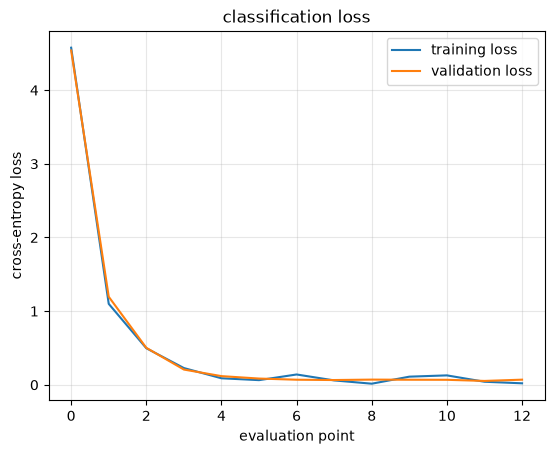

In [39]:
# plot loss

evaluation_points = range(
    len(training_losses)
)

plt.plot(
    evaluation_points,
    training_losses,
    label="training loss",
)

plt.plot(
    evaluation_points,
    validation_losses,
    label="validation loss",
)

plt.xlabel("evaluation point")
plt.ylabel("cross-entropy loss")
plt.title("classification loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

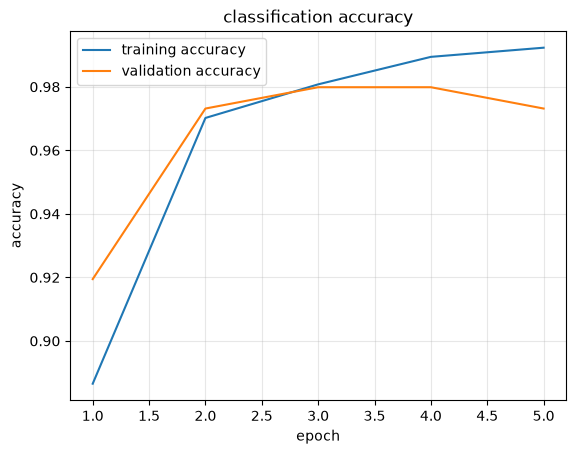

In [40]:
# plot accuracy

epochs = range(
    1,
    number_of_epochs + 1,
)

plt.plot(
    epochs,
    training_accuracies,
    label="training accuracy",
)

plt.plot(
    epochs,
    validation_accuracies,
    label="validation accuracy",
)

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("classification accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [42]:
# final test evaluation

test_loss = calculate_loader_loss(
    test_loader,
    model,
    device,
)

test_accuracy = calculate_accuracy(
    test_loader,
    model,
    device,
)

print("test loss:", test_loss)
print("test accuracy:", test_accuracy)

test loss: 0.06781498794934075
test accuracy: 0.9666666666666667


In [44]:
# calculate precision, recall, and F1 score

def calculate_classification_metrics(
    data_loader,
    model,
    device,
):
    model.eval()

    true_positives = 0
    true_negatives = 0
    false_positives = 0
    false_negatives = 0

    with torch.no_grad():
        for (
            input_batch,
            label_batch,
            length_batch,
        ) in data_loader:
            input_batch = (
                input_batch.to(device)
            )

            label_batch = (
                label_batch.to(device)
            )

            length_batch = (
                length_batch.to(device)
            )

            logits = (
                get_classification_logits(
                    model,
                    input_batch,
                    length_batch,
                )
            )

            predictions = torch.argmax(
                logits,
                dim=-1,
            )

            true_positives += (
                (
                    predictions == 1
                )
                & (
                    label_batch == 1
                )
            ).sum().item()

            true_negatives += (
                (
                    predictions == 0
                )
                & (
                    label_batch == 0
                )
            ).sum().item()

            false_positives += (
                (
                    predictions == 1
                )
                & (
                    label_batch == 0
                )
            ).sum().item()

            false_negatives += (
                (
                    predictions == 0
                )
                & (
                    label_batch == 1
                )
            ).sum().item()

    precision = (
        true_positives
        / (
            true_positives
            + false_positives
        )
        if (
            true_positives
            + false_positives
        ) > 0
        else 0.0
    )

    recall = (
        true_positives
        / (
            true_positives
            + false_negatives
        )
        if (
            true_positives
            + false_negatives
        ) > 0
        else 0.0
    )

    f1_score = (
        2
        * precision
        * recall
        / (
            precision + recall
        )
        if (
            precision + recall
        ) > 0
        else 0.0
    )

    return {
        "true positives": (
            true_positives
        ),
        "true negatives": (
            true_negatives
        ),
        "false positives": (
            false_positives
        ),
        "false negatives": (
            false_negatives
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1_score,
    }


test_metrics = (
    calculate_classification_metrics(
        test_loader,
        model,
        device,
    )
)

for metric, value in (
    test_metrics.items()
):
    print(metric, value)

true positives 145
true negatives 145
false positives 4
false negatives 6
precision 0.9731543624161074
recall 0.9602649006622517
f1 0.9666666666666668


In [46]:
# define a function to classify a single message as spam or not spam

def classify_message(
    text,
    model,
    tokenizer,
    device,
    max_length,
    pad_token_id=50256,
):
    model.eval()

    token_ids = tokenizer.encode(
        text
    )

    if len(token_ids) == 0:
        token_ids = [
            pad_token_id
        ]

    token_ids = token_ids[
        :max_length
    ]

    text_length = len(
        token_ids
    )

    token_ids += [
        pad_token_id
    ] * (
        max_length
        - text_length
    )

    input_tensor = torch.tensor(
        token_ids,
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    length_tensor = torch.tensor(
        [text_length],
        dtype=torch.long,
        device=device,
    )

    with torch.no_grad():
        logits = (
            get_classification_logits(
                model,
                input_tensor,
                length_tensor,
            )
        )

    probabilities = torch.softmax(
        logits,
        dim=-1,
    )

    predicted_label = torch.argmax(
        probabilities,
        dim=-1,
    ).item()

    spam_probability = (
        probabilities[0, 1].item()
    )

    label_name = (
        "spam"
        if predicted_label == 1
        else "not spam"
    )

    return (
        label_name,
        spam_probability,
    )

In [48]:
# test new messages

spam_message = (
    "You are a winner. Claim your "
    "$1000 cash prize now."
)

normal_message = (
    "Hey, are we still meeting "
    "for dinner tonight?"
)

print(
    classify_message(
        spam_message,
        model,
        tokenizer,
        device,
        max_length,
    )
)

print(
    classify_message(
        normal_message,
        model,
        tokenizer,
        device,
        max_length,
    )
)

('spam', 0.9843422770500183)
('not spam', 0.00020094114006496966)


In [50]:
# save the classifer

classifier_path = (
    models_folder
    / "gpt2_spam_classifier.pth"
)

torch.save(
    {
        "model_state_dict": (
            model.state_dict()
        ),
        "gpt2_config": (
            gpt2_config
        ),
        "max_length": max_length,
        "number_of_classes": 2,
        "label_names": {
            0: "not spam",
            1: "spam",
        },
        "classification_position": (
            "last non-padding token"
        ),
    },
    classifier_path,
)

print(
    "saved classifier:",
    classifier_path,
)

saved classifier: models/gpt2_spam_classifier.pth
